# Importación de librerías y configuración del entorno

In [ ]:
import os
import random

from catboost import CatBoostClassifier
import cupy as cp
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgbm
import matplotlib.pyplot as plt
import numpy as np
import optuna
from optuna.exceptions import ExperimentalWarning
from optuna.integration import CatBoostPruningCallback, LightGBMPruningCallback, XGBoostPruningCallback
from optuna.samplers import TPESampler
import pandas as pd
import xgboost as xgb
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, RobustScaler
import warnings
import xgboost as xgb

In [2]:
try:
    # Crear un array de prueba para verificar que CuPy está funcionando
    test_array = cp.array([1, 2, 3])
    print(f"CuPy está funcionando en: {test_array.device}")
except Exception as e:
    print(f"CuPy falló: {e}")

CuPy está funcionando en: <CUDA Device 0>


In [3]:
def set_global_seed(seed: int = 42):
    """
    Fija semillas para asegurar reproducibilidad en experimentos.
    """
    # Entorno y Python
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    print(f"Semillas fijadas en {seed}")

In [4]:
SEED = 42
set_global_seed(SEED)

Semillas fijadas en 42


# Carga y preprocesamiento de datasets

## Carga y preprocesamiento inicial

In [5]:
# Cargar datasets
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test_x.csv')

In [6]:
train.head(5)

,Id,Edad,Trabajo,Estado Civil,Educacion,Credito por Defecto,Prestamo Vivienda,Prestamo Personal,Contacto,Mes,...,Cantidad Contactos Realizados,Cantidad Dias desde Ultimo Contacto,Cantidad Contactos Previos Realizados,Resultado Campaña Anterior,Tasa Variacion Empleo,Indice Precios Consumidor,Indice Confianza Consumidor,Tasa Interes 3 meses,Cantidad Empleados,Subscripcion Deposito
0,0,44,tecnico,divorciado,curso_profesional,no,no,si,telefono,junio,...,2,999,0,inexistente,1.4,94.465,-41.8,4.961,5228.1,no
1,1,30,administrador,soltero,grado_universitario,no,no,si,celular,julio,...,2,999,0,inexistente,1.4,93.918,-42.7,4.961,5228.1,no
2,2,41,administración,casado,secundaria_completa,valor_que_falta,no,no,celular,mayo,...,1,999,0,inexistente,-1.8,92.893,-46.2,1.291,5099.1,no
3,3,31,trabajador_industria,soltero,primaria_4_grado,valor_que_falta,si,no,celular,mayo,...,1,999,0,inexistente,-1.8,92.893,-46.2,1.250,5099.1,no
4,4,35,empleado_ por_cuenta_propia,casado,grado_universitario,no,si,no,celular,julio,...,1,999,0,inexistente,1.4,93.918,-42.7,4.958,5228.1,no


In [7]:
test.head(5)

,Id,Edad,Trabajo,Estado Civil,Educacion,Credito por Defecto,Prestamo Vivienda,Prestamo Personal,Contacto,Mes,...,Duracion,Cantidad Contactos Realizados,Cantidad Dias desde Ultimo Contacto,Cantidad Contactos Previos Realizados,Resultado Campaña Anterior,Tasa Variacion Empleo,Indice Precios Consumidor,Indice Confianza Consumidor,Tasa Interes 3 meses,Cantidad Empleados
0,0,30,trabajador_industria,casado,primaria_3_grado,no,si,no,celular,mayo,...,487,2,999,0,inexistente,-1.8,92.893,-46.2,1.313,5099.1
1,1,39,servicios,soltero,secundaria_completa,no,no,no,telefono,mayo,...,346,4,999,0,inexistente,1.1,93.994,-36.4,4.855,5191.0
2,2,25,servicios,casado,secundaria_completa,no,si,no,telefono,junio,...,227,1,999,0,inexistente,1.4,94.465,-41.8,4.962,5228.1
3,3,38,servicios,casado,primaria_3_grado,no,valor_que_falta,valor_que_falta,telefono,junio,...,17,3,999,0,inexistente,1.4,94.465,-41.8,4.959,5228.1
4,4,47,administrador,casado,grado_universitario,no,si,no,celular,noviembre,...,58,1,999,0,inexistente,-0.1,93.200,-42.0,4.191,5195.8


In [8]:
train.dtypes

Id                                         int64
Edad                                       int64
Trabajo                                      str
Estado Civil                                 str
Educacion                                    str
Credito por Defecto                          str
Prestamo Vivienda                            str
Prestamo Personal                            str
Contacto                                     str
Mes                                          str
Dia Semana                                   str
Duracion                                   int64
Cantidad Contactos Realizados              int64
Cantidad Dias desde Ultimo Contacto        int64
Cantidad Contactos Previos Realizados      int64
Resultado Campaña Anterior                   str
Tasa Variacion Empleo                    float64
Indice Precios Consumidor                float64
Indice Confianza Consumidor              float64
Tasa Interes 3 meses                     float64
Cantidad Empleados  

In [9]:
# Preprocesamiento inicial
def preprocess(df, is_train=True):
    # Descartar la ID y la variable 'Duracion'
    df = df.drop(columns=['Id', 'Duracion'])

    # Manejo de nulos explícitos
    df = df.replace('valor_que_falta', np.nan)

    # Crear variable binaria para clientes nunca contactados
    df['nunca_contactado'] = (df['Cantidad Dias desde Ultimo Contacto'] == 999).astype(int)

    # Convertir el valor 999 a NaN en la columna original
    df['Cantidad Dias desde Ultimo Contacto'] = df['Cantidad Dias desde Ultimo Contacto'].replace(999, np.nan)
    
    # Convertir variables categóricas binarias a numéricas
    binary_cols = [
        'Credito por Defecto',
        'Prestamo Vivienda',
        'Prestamo Personal',
        'Subscripcion Deposito'
    ]
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map({'no': 0, 'si': 1})

    return df

train_df = train.copy()
test_df = test.copy()

train_df = preprocess(train_df)
test_df = preprocess(test_df, is_train=False)

## Análisis de características

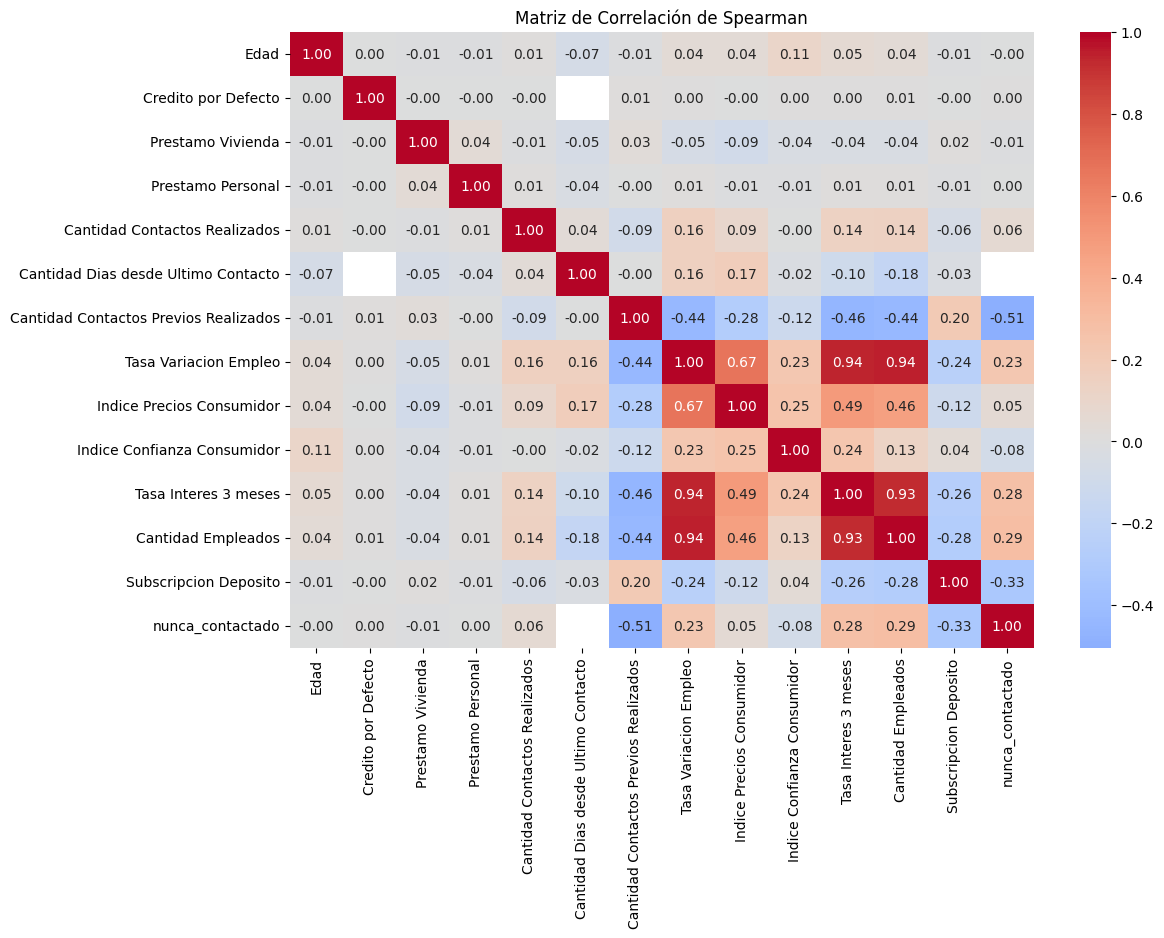

In [10]:
def show_correlation_matrix(df, save_name='correlation_matrix.svg'):
    # Seleccionar solo las numéricas para la matriz
    numeric_cols = df.select_dtypes(include=[np.number, np.float64]).columns
    corr_matrix = df[numeric_cols].corr(method='spearman')

    # Visualización rápida
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title("Matriz de Correlación de Spearman")
    plt.savefig(f'../images/{save_name}', format='svg', bbox_inches='tight')
    plt.show()

show_correlation_matrix(train_df, save_name='correlation_matrix_spearman_before.svg')

In [11]:
# Variables económicas redundantes
econ_cols = ['Tasa Variacion Empleo', 'Tasa Interes 3 meses', 'Cantidad Empleados']

# Escalar las variables económicas antes de aplicar PCA
scaler = RobustScaler()
train_econ_scaled = scaler.fit_transform(train_df[econ_cols])
test_econ_scaled = scaler.transform(test_df[econ_cols])

# Extraer solo el primer componente
pca = PCA(n_components=1)
train_df['ISE_Econ'] = pca.fit_transform(train_econ_scaled)
test_df['ISE_Econ'] = pca.transform(test_econ_scaled)

# Eliminar las variables económicas redundantes
train_df = train_df.drop(columns=econ_cols)
test_df = test_df.drop(columns=econ_cols)

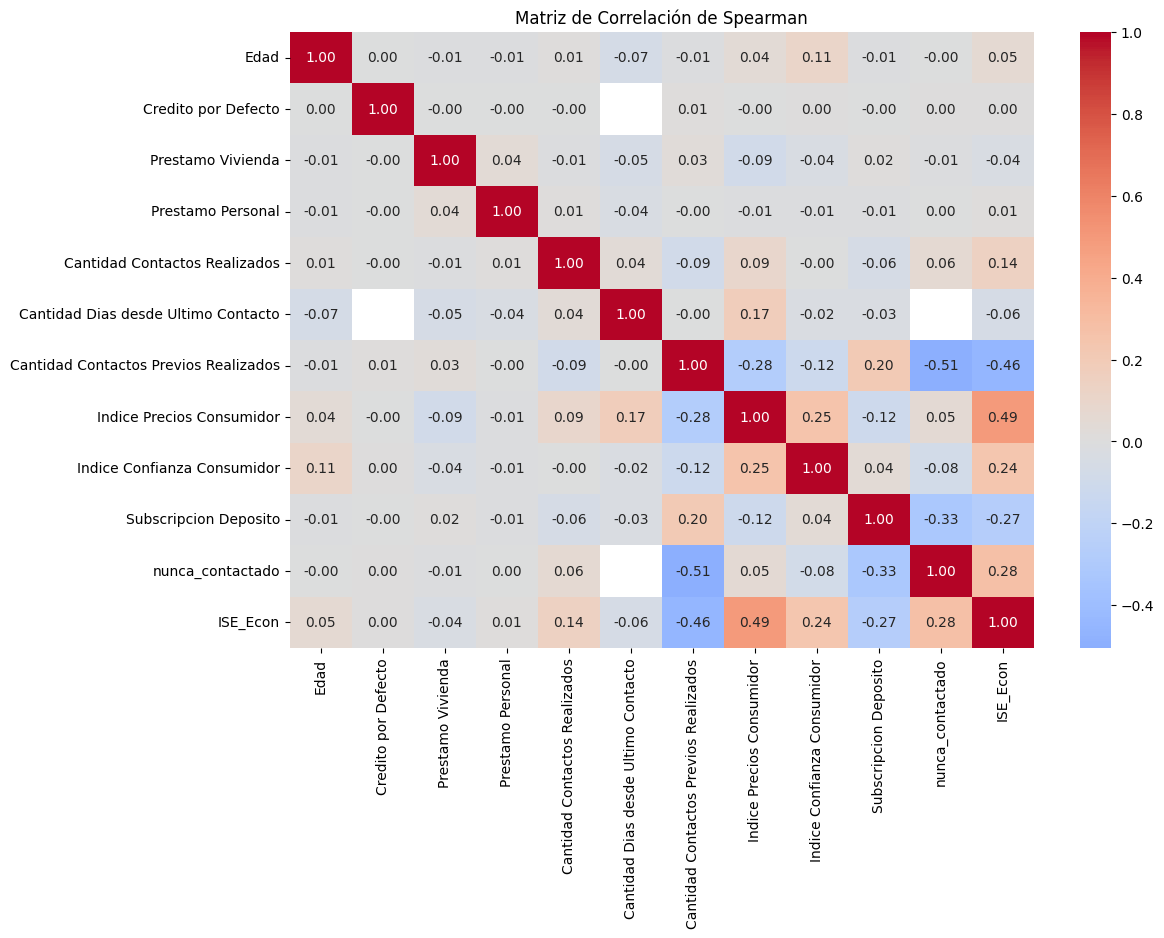

In [12]:
show_correlation_matrix(train_df, save_name='correlation_matrix_spearman_after.svg')

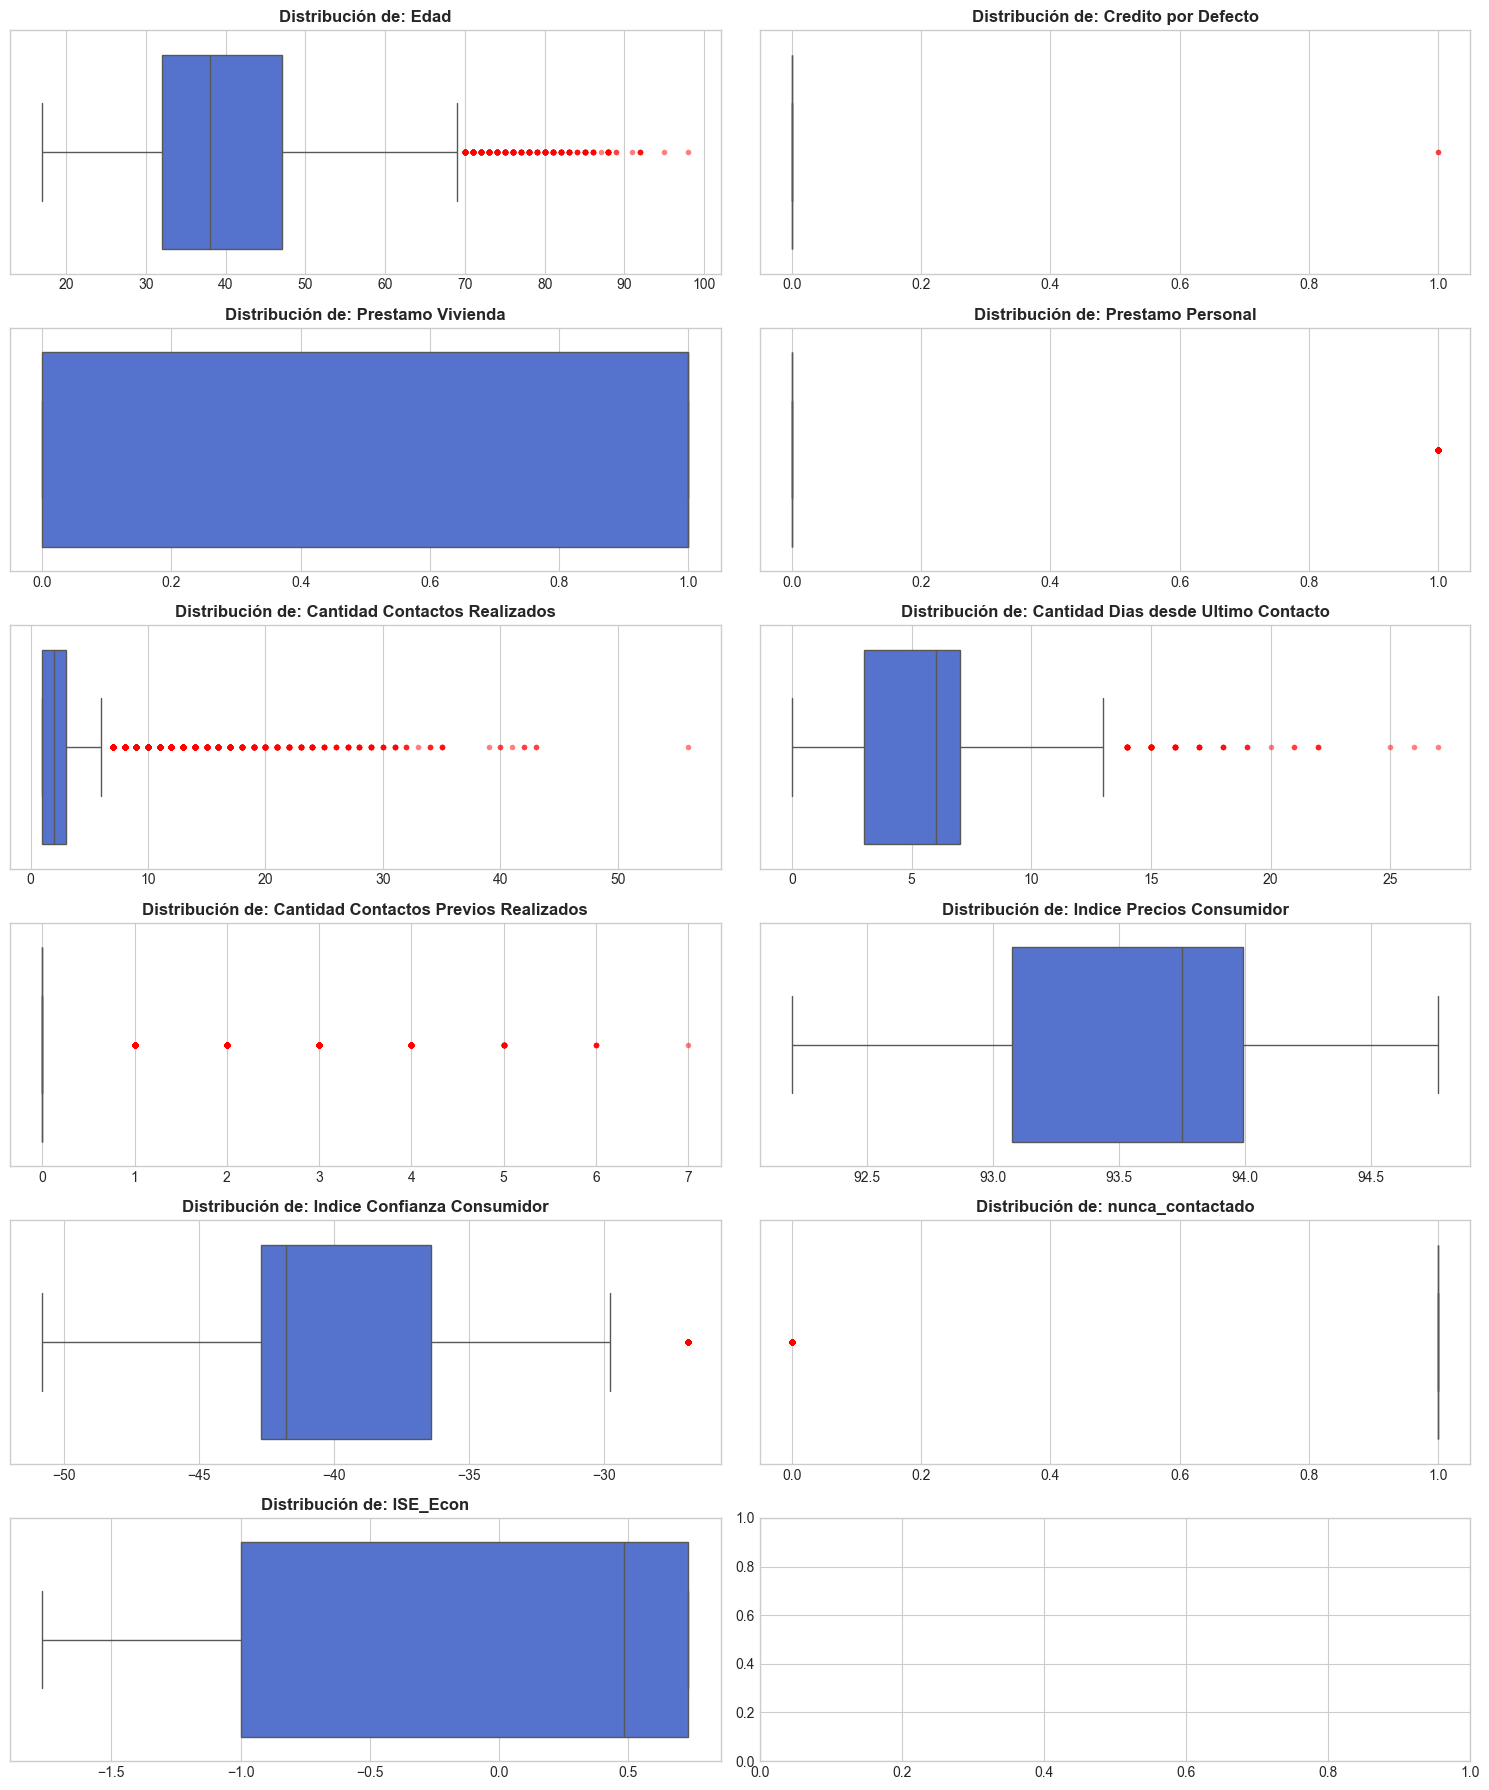

In [13]:
warnings.filterwarnings('ignore')

def show_boxplots(df, save_name='boxplots.svg'):
    # Seleccionar solo las numéricas para el análisis de outliers
    numeric_features = df.select_dtypes(
        include=[np.number, np.float64]).columns.drop(['Subscripcion Deposito']).tolist()

    plt.style.use('seaborn-v0_8-whitegrid')

    # Crear una cuadrícula dinámica
    fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 18))
    axes = axes.flatten() # Aplanar el arreglo de ejes para iterar fácilmente

    # Iterar sobre cada variable y dibujar su boxplot
    for i, col in enumerate(numeric_features):
        sns.boxplot(
            x=df[col], 
            ax=axes[i], 
            color='royalblue', 
            fliersize=4, 
            flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.5, 'markeredgecolor': 'none'} # Pintar los outliers de rojo
        )
        axes[i].set_title(f'Distribución de: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')

    plt.tight_layout()

    plt.savefig(f'../images/{save_name}', format='svg', bbox_inches='tight')
    plt.show()

show_boxplots(train_df, save_name='outlier_analysis_boxplots_before.svg')

In [14]:
# Clase personalizada para tratamiento de atípicos
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_percentile=1.0, upper_percentile=99.0):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        
    def fit(self, X, y=None):
        # Calcular los techos y pisos matemáticos durante el entrenamiento
        # Ignorar los NaNs para no fallar si el imputer aún no ha actuado
        self.lower_bounds_ = np.nanpercentile(X, self.lower_percentile, axis=0)
        self.upper_bounds_ = np.nanpercentile(X, self.upper_percentile, axis=0)
        return self

    def transform(self, X, y=None):
        # Comprimir cualquier valor que se salga de los límites
        X_clipped = np.clip(X, self.lower_bounds_, self.upper_bounds_)
        return X_clipped

In [15]:
class IQROutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, multiplier=1.5):
        self.multiplier = multiplier
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        
    def fit(self, X, y=None):
        # Calcular los cuartiles ignorando los NaNs para no fallar si el imputer aún no ha actuado
        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)
        
        # Calcular el rango intercuartílico (IQR)
        iqr = q3 - q1
        
        # Definir los límites de Tukey para el capping de outliers
        self.lower_bounds_ = q1 - (self.multiplier * iqr)
        self.upper_bounds_ = q3 + (self.multiplier * iqr)
        
        return self

    def transform(self, X, y=None):
        # Aplicar el capping de outliers usando los límites calculados
        X_clipped = np.clip(X, self.lower_bounds_, self.upper_bounds_)
        return X_clipped

In [16]:
# Definir la lista de variables continuas que requieren capping
# (se excluyen las binarias, macroeconómicas estables y conteos asimétricos naturales)
variables_to_cap = [
    'Edad', 
    'Cantidad Contactos Realizados', 
    'Cantidad Dias desde Ultimo Contacto',
    'Indice Confianza Consumidor'
]

def outlier_capping(df, variables, df_type='train'):
    # Instanciar el tratador de atípicos
    global_capper = OutlierCapper(lower_percentile=1.0, upper_percentile=99.0)

    # Aplicar el filtro únicamente a esa lista en el dataset de entrenamiento
    # En test se usa solo transform para evitar data leakage
    X_continuous = df[variables].copy()
    
    if df_type == 'train':
        X_continuous_clean_array = global_capper.fit_transform(X_continuous)
    else:
        X_continuous_clean_array = global_capper.transform(X_continuous)

    X_continuous_clean = pd.DataFrame(
        X_continuous_clean_array,
        columns=variables_to_cap,
        index=df.index
    ).astype(X_continuous.dtypes)

    df.loc[:, variables_to_cap] = X_continuous_clean

    return df

train_df = outlier_capping(train_df, variables_to_cap, df_type='train')
test_df = outlier_capping(test_df, variables_to_cap, df_type='test')

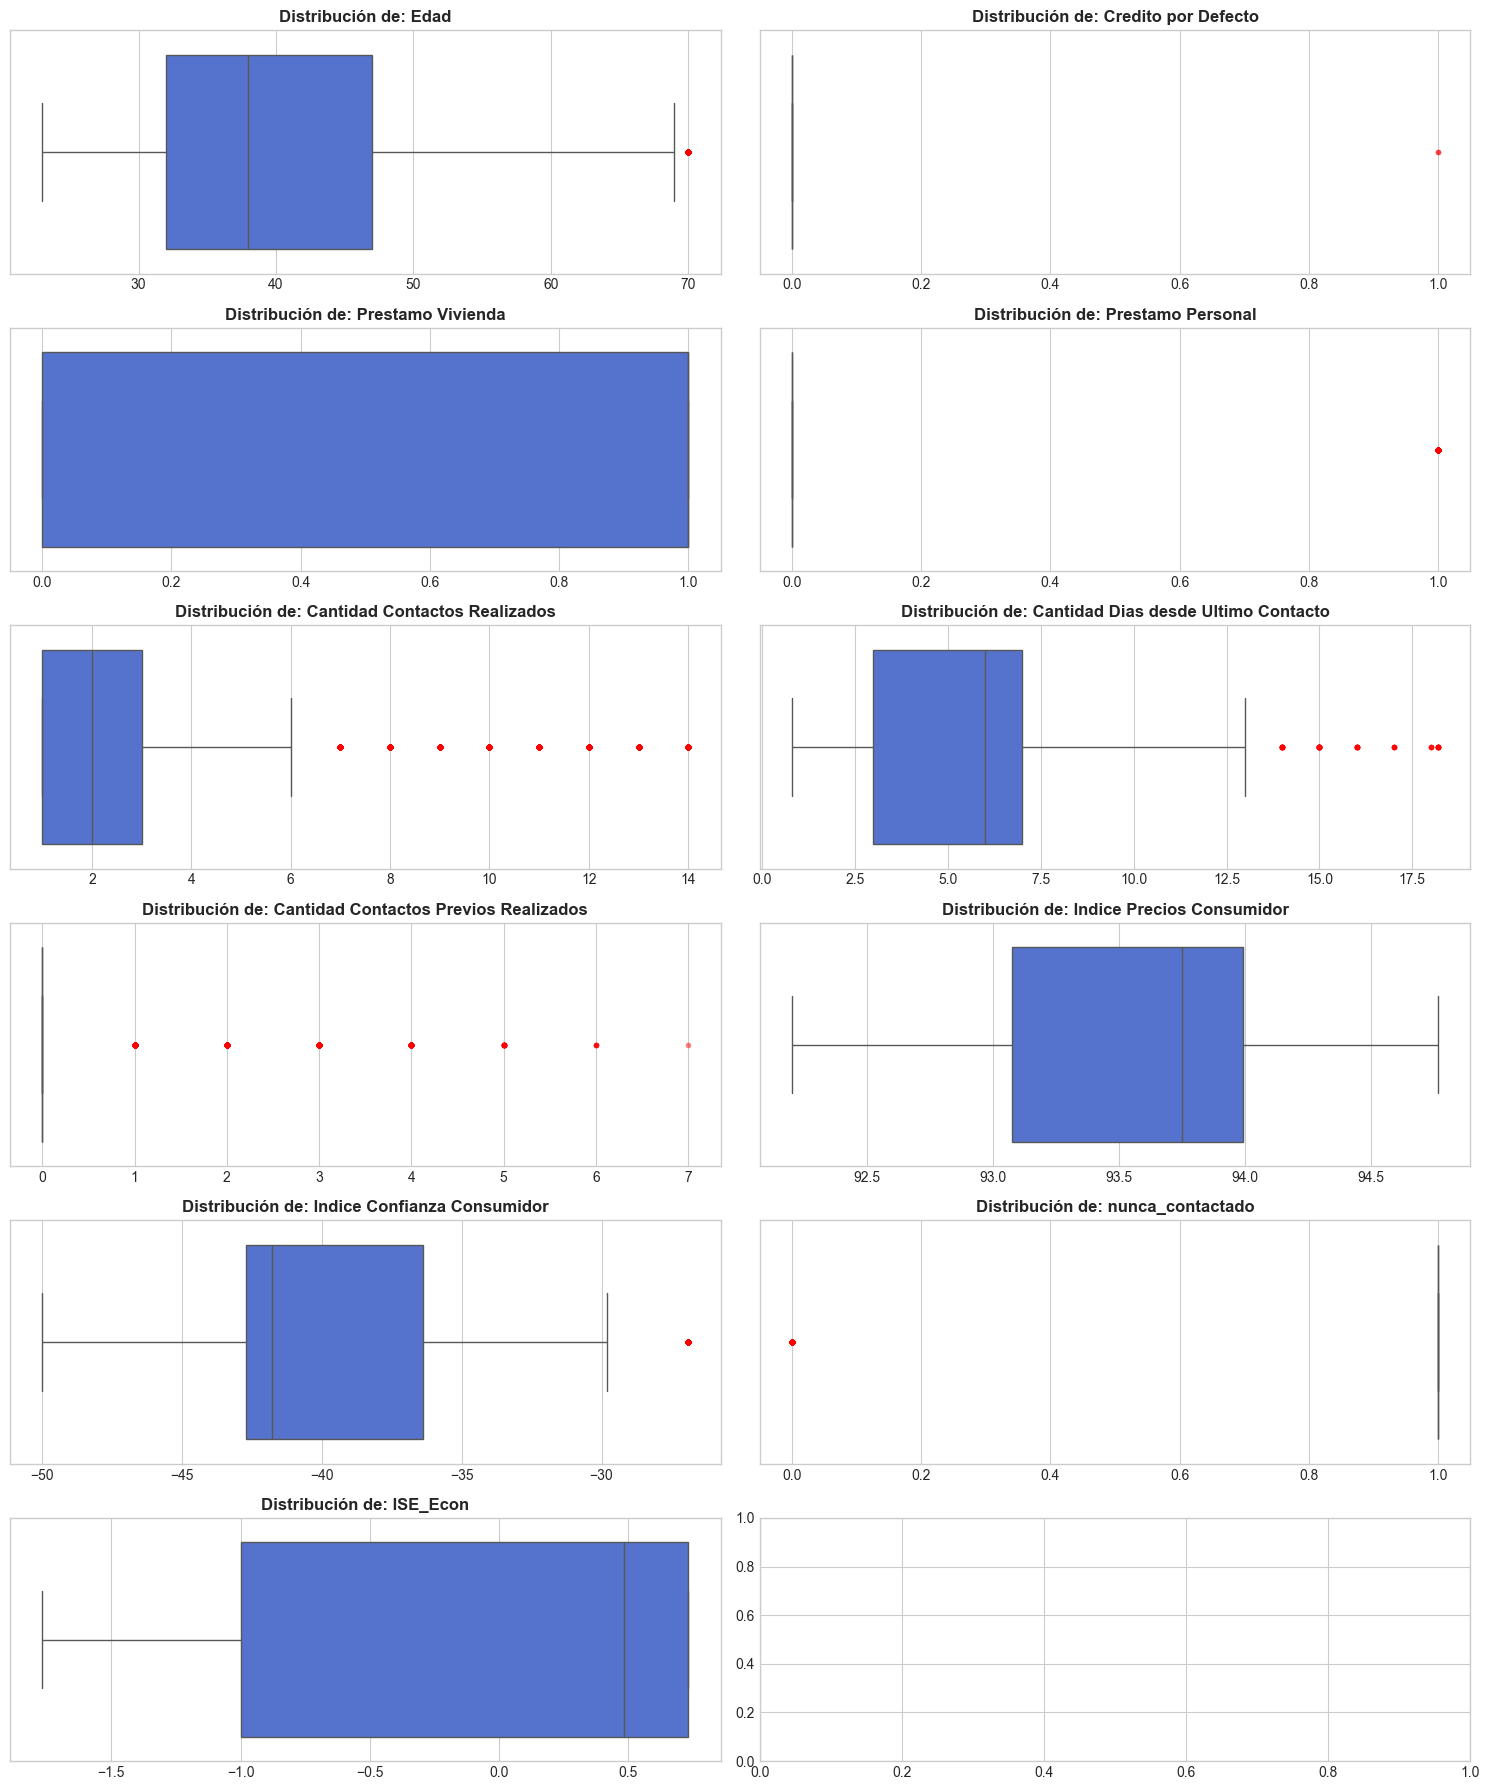

In [17]:
show_boxplots(train_df, save_name='outlier_analysis_boxplots_after.svg')

## Preprocesamiento final

In [18]:
# Definir cortes de edad
age_bins = [0, 25, 35, 45, 55, 65, np.inf]
age_labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '65+']

train_df['rango_edad'] = pd.cut(train_df['Edad'], bins=age_bins, labels=age_labels)
test_df['rango_edad'] = pd.cut(test_df['Edad'], bins=age_bins, labels=age_labels)

train_df = train_df.drop(columns=['Edad'])
test_df = test_df.drop(columns=['Edad'])

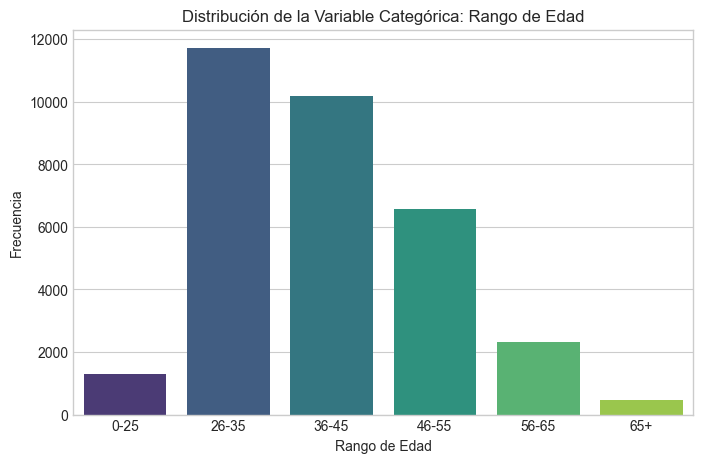

In [19]:
# Ver la distribución de la nueva variable categórica
plt.figure(figsize=(8, 5))
sns.countplot(x='rango_edad', data=train_df, palette='viridis')
plt.title('Distribución de la Variable Categórica: Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Frecuencia')
plt.savefig('../images/rango_edad_distribution_bins.svg', format='svg', bbox_inches='tight')
plt.show()

Aplicamos label encoding a las variables categóricas con un orden lógico.

In [20]:
# Orden lógico de 'Educacion'
educacion_map = {
    'analfabeto': 0,
    'primaria_3_grado': 1,
    'primaria_4_grado': 2,
    'primaria_6_grado': 3,
    'secundaria_completa': 4,
    'curso_profesional': 5,
    'grado_universitario': 6,
    'valor_que_falta': np.nan
}

# Orden lógico de 'Mes'
mes_map = {
    'enero': 1,
    'febrero': 2,
    'marzo': 3,
    'abril': 4,
    'mayo': 5,
    'junio': 6,
    'julio': 7,
    'agosto': 8,
    'septiembre': 9,
    'octubre': 10,
    'noviembre': 11,
    'diciembre': 12
}

# Orden lógico de 'Dia Semana'
dia_semana_map = {
    'lunes': 1,
    'martes': 2,
    'miercoles': 3,
    'jueves': 4,
    'viernes': 5
}

# Orden lógico de 'rango_edad'
rango_edad_map = {
    '0-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-55': 4,
    '56-65': 5,
    '65+': 6
}

In [21]:
def label_encode_categoricals(df, map, col_name):
    if col_name in df.columns:
        df[col_name] = df[col_name].map(map)
    return df

feature_maps = {
    'Educacion': educacion_map,
    'Mes': mes_map,
    'Dia Semana': dia_semana_map,
    'rango_edad': rango_edad_map
}

for col, map in feature_maps.items():
    train_df = label_encode_categoricals(train_df, map, col)
    test_df = label_encode_categoricals(test_df, map, col)

Aplicamos one-hot encoding a las variables categóricas sin un orden lógico.

In [22]:
ohe_nominal_cols = ['Trabajo', 'Estado Civil', 'Contacto', 'Resultado Campaña Anterior']

# Combinar train y test para asegurar consistencia en el encoding
combined = pd.concat([train_df, test_df], axis=0)

# Aplicar one-hot encoding a las variables nominales
combined_encoded = pd.get_dummies(combined, columns=ohe_nominal_cols, prefix=ohe_nominal_cols, drop_first=True)

# Separar nuevamente en train y test
train_df = combined_encoded.iloc[:len(train_df), :].copy()
test_df = combined_encoded.iloc[len(train_df):, :].copy()

# Remover el target del test si es que se añadió por error
if 'Subscripcion Deposito' in test_df.columns:
    test_df = test_df.drop(columns=['Subscripcion Deposito'])

# Convertir los valores booleanos a enteros (0 y 1)
bool_cols = train_df.select_dtypes(include=['bool']).columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
test_df[bool_cols] = test_df[bool_cols].astype(int)

In [23]:
train_df.head(5)

,Educacion,Credito por Defecto,Prestamo Vivienda,Prestamo Personal,Mes,Dia Semana,Cantidad Contactos Realizados,Cantidad Dias desde Ultimo Contacto,Cantidad Contactos Previos Realizados,Indice Precios Consumidor,...,Trabajo_estudiante,Trabajo_retirado,Trabajo_servicios,Trabajo_tecnico,Trabajo_trabajador_industria,Estado Civil_divorciado,Estado Civil_soltero,Contacto_telefono,Resultado Campaña Anterior_fallido,Resultado Campaña Anterior_inexistente
0,5.0,0.0,0.0,1.0,6,2,2,NaN,0,94.465,...,0,0,0,1,0,1,0,1,0,1
1,6.0,0.0,0.0,1.0,7,2,2,NaN,0,93.918,...,0,0,0,0,0,0,1,0,0,1
2,4.0,NaN,0.0,0.0,5,2,1,NaN,0,92.893,...,0,0,0,0,0,0,0,0,0,1
3,2.0,NaN,1.0,0.0,5,5,1,NaN,0,92.893,...,0,0,0,0,1,0,1,0,0,1
4,6.0,0.0,1.0,0.0,7,4,1,NaN,0,93.918,...,0,0,0,0,0,0,0,0,0,1


# Entrenamiento del modelo

In [24]:
# Separar características y target
X = train_df.drop(columns=['Subscripcion Deposito'])
y = train_df['Subscripcion Deposito']

# Verificar el tamaño
print(f"Tamaño de X: {X.shape}")
print(f"Tamaño de y: {y.shape}")

Tamaño de X: (32538, 29)
Tamaño de y: (32538,)


In [25]:
# Pasar los datos a la GPU
X_gpu = cp.array(X.values)
y_gpu = cp.array(y.values)

In [26]:
# Calcular el peso de las clases para manejar el desbalance
class_weights = y.value_counts()
scale_pos_weight = class_weights[0] / class_weights[1]

print(f"Peso de la clase positiva: {scale_pos_weight:.2f}")

Peso de la clase positiva: 7.88


## Optimización de hiperparámetros

### XGBoost

In [42]:
def objective_xgb(trial):
    # Definir los hiperparámetros a optimizar
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 5000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight * 0.8, scale_pos_weight * 1.2),
        'early_stopping_rounds': 100,
        'n_jobs': -1,
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': SEED,
        'eval_metric': 'auc'
    }

    # K-Fold Cross Validation con estratificación para manejar el desbalance de clases
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)
    oof_preds = np.zeros(X.shape[0])
    best_iterations = []

    for fold_idx, (train_idx, val_idx) in enumerate(rskf.split(X, y)):
        X_train_fold, X_val_fold = X_gpu[train_idx], X_gpu[val_idx]
        y_train_fold, y_val_fold = y_gpu[train_idx], y_gpu[val_idx]

        callbacks_list = []

        if fold_idx == 0:
            pruning_callback = XGBoostPruningCallback(trial, observation_key="validation_0-auc")
            callbacks_list.append(pruning_callback)

        model = xgb.XGBClassifier(**params, callbacks=callbacks_list)
        
        # Entrenamos el modelo con early stopping para evitar overfitting y pruning para descartar configuraciones no prometedoras
        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            verbose=False,
        )

        # Guardar la mejor iteración para análisis posterior
        best_iterations.append(model.best_iteration)

        # Obtener las predicciones y moverlas a la CPU
        preds = cp.asnumpy(model.predict_proba(X_val_fold)[:, 1])

        # Acumular las predicciones OOF para análisis posterior
        oof_preds[val_idx] += preds / 2
    
    # Calcular un único AUC global sobre todo el conjunto de validación OOF
    auc_global = roc_auc_score(cp.asnumpy(y), oof_preds)

    # Guardar métricas adicionales en el objeto de estudio para análisis posterior
    trial.set_user_attr("avg_best_iteration", int(np.mean(best_iterations)))

    return auc_global

In [43]:
# Ejecutar el estudio
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

[I 2026-05-16 18:15:09,061] A new study created in memory with name: no-name-95bb0183-9580-4070-8fad-c53d88ddff18


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-16 18:15:13,951] Trial 0 finished with value: 0.7930218117946933 and parameters: {'n_estimators': 2185, 'max_depth': 8, 'learning_rate': 0.044803926826840625, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 12, 'gamma': 2.9152036385288193e-08, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'scale_pos_weight': 8.531093449659295}. Best is trial 0 with value: 0.7930218117946933.
[I 2026-05-16 18:15:18,043] Trial 1 finished with value: 0.7959835694073901 and parameters: {'n_estimators': 592, 'max_depth': 8, 'learning_rate': 0.060534484680010825, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'min_child_weight': 13, 'gamma': 2.716051144654844e-06, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'scale_pos_weight': 7.217934286502769}. Best is trial 1 with value: 0.7959835694073901.
[I 2026-05-16 18:15:33,659] Trial 2 finished with value: 0.8007281078990105 and paramet

In [44]:
print(f"Mejor AUC: {study_xgb.best_value}")
print(f"Mejores Parámetros: {study_xgb.best_params}")

Mejor AUC: 0.8025261611459016
Mejores Parámetros: {'n_estimators': 4025, 'max_depth': 7, 'learning_rate': 0.06749859700060529, 'subsample': 0.9146833629004048, 'colsample_bytree': 0.6422527589020836, 'min_child_weight': 34, 'gamma': 4.1829555447551794e-07, 'reg_alpha': 9.208725348206892e-08, 'reg_lambda': 0.0031079101622357563, 'scale_pos_weight': 8.824075404860737}


### LightGBM

In [45]:
def objective_lgbm(trial):
    # Definir los hiperparámetros a optimizar
    max_depth = trial.suggest_int('max_depth', 3, 10)
    max_leaves = 2**max_depth # Calcular el número máximo de hojas basado en la profundidad para evitar configuraciones inválidas
    num_leaves = trial.suggest_int('num_leaves', 8, max_leaves)

    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': SEED,
        'device': 'cpu',
        'n_jobs': -1,
        'n_estimators': 5000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': num_leaves,
        'max_depth': max_depth,
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight * 0.8, scale_pos_weight * 1.2)
    }

    # K-Fold Cross Validation con estratificación para manejar el desbalance de clases
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)
    oof_preds = np.zeros(X.shape[0])
    best_iterations = []

    for fold_idx, (train_idx, val_idx) in enumerate(rskf.split(X, y)):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model = lgbm.LGBMClassifier(**params)

        callbacks_list = [
            lgbm.early_stopping(stopping_rounds=100, verbose=False),
            lgbm.log_evaluation(period=0)
        ]

        if fold_idx == 0:
            pruning_callback = LightGBMPruningCallback(trial, "auc", valid_name="valid_0")
            callbacks_list.append(pruning_callback)
        
        # Entrenar el modelo con early stopping para evitar overfitting y pruning para descartar configuraciones no prometedoras
        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            callbacks=callbacks_list,
        )

        # Guardar la mejor iteración para análisis posterior
        best_iterations.append(model.best_iteration_)

        # Obtener las predicciones
        preds = model.predict_proba(X_val_fold)[:, 1]

        # Acumular las predicciones OOF para análisis posterior
        oof_preds[val_idx] += preds / 2
    
    # Calcular un único AUC global sobre todo el conjunto de validación OOF
    auc_global = roc_auc_score(y, oof_preds)

    # Guardar métricas adicionales en el objeto de estudio para análisis posterior
    trial.set_user_attr("avg_best_iteration", int(np.mean(best_iterations)))

    return auc_global

In [46]:
# Ejecutar el estudio
study_lgbm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_lgbm.optimize(objective_lgbm, n_trials=100, show_progress_bar=True)

[I 2026-05-16 18:16:38,939] A new study created in memory with name: no-name-7e398320-422d-4cf6-a475-8c71b92164fd


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-16 18:16:55,516] Trial 0 finished with value: 0.8022804711186815 and parameters: {'max_depth': 5, 'num_leaves': 31, 'learning_rate': 0.044803926826840625, 'min_child_samples': 62, 'feature_fraction': 0.4936111842654619, 'subsample': 0.49359671220172163, 'subsample_freq': 1, 'lambda_l1': 0.6245760287469893, 'lambda_l2': 0.002570603566117598, 'scale_pos_weight': 8.531093449659295}. Best is trial 0 with value: 0.8022804711186815.
[I 2026-05-16 18:17:13,023] Trial 1 finished with value: 0.8005255470767224 and parameters: {'max_depth': 3, 'num_leaves': 8, 'learning_rate': 0.09138013915892866, 'min_child_samples': 84, 'feature_fraction': 0.5274034664069657, 'subsample': 0.5090949803242604, 'subsample_freq': 2, 'lambda_l1': 5.472429642032198e-06, 'lambda_l2': 0.00052821153945323, 'scale_pos_weight': 7.661223849234607}. Best is trial 0 with value: 0.8022804711186815.
[I 2026-05-16 18:17:49,245] Trial 2 finished with value: 0.7932048487392176 and parameters: {'max_depth': 5, 'num_lea

In [47]:
print(f"Mejor AUC: {study_lgbm.best_value}")
print(f"Mejores Parámetros: {study_lgbm.best_params}")

Mejor AUC: 0.8024862252972165
Mejores Parámetros: {'max_depth': 7, 'num_leaves': 30, 'learning_rate': 0.09129115219600122, 'min_child_samples': 79, 'feature_fraction': 0.9636993649385135, 'subsample': 0.9368964102565893, 'subsample_freq': 5, 'lambda_l1': 1.9809253750493907, 'lambda_l2': 6.257956190096665e-08, 'scale_pos_weight': 6.917885128615992}


### CatBoost

In [48]:
warnings.filterwarnings("ignore", category=ExperimentalWarning)

def objective_catboost(trial):
    # Definir los hiperparámetros a optimizar
    params = {
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight * 0.8, scale_pos_weight * 1.2),
        'one_hot_max_size': 254,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'thread_count': -1,
        'random_seed': SEED,
        'verbose': False,
        'allow_writing_files': False
    }

    # Se le debe indicar a CatBoost cuáles son las variables categóricas para que pueda manejarlas de forma nativa y eficiente
    cat_features_list = X.select_dtypes(include=['category', 'object']).columns.tolist()

    # K-Fold Cross Validation con estratificación para manejar el desbalance de clases
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)
    oof_preds = np.zeros(X.shape[0])
    best_iterations = []

    for fold_idx, (train_idx, val_idx) in enumerate(rskf.split(X, y)):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        pruning_callback = CatBoostPruningCallback(trial, "AUC")

        callbacks_list = []
        
        if fold_idx == 0:
            pruning_callback = CatBoostPruningCallback(trial, "AUC")
            callbacks_list.append(pruning_callback)
        
        model = CatBoostClassifier(**params)

        # Entrenar el modelo con early stopping para evitar overfitting y pruning para descartar configuraciones no prometedoras
        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            cat_features=cat_features_list,
            early_stopping_rounds=100,
            callbacks=callbacks_list,
            verbose=False
        )

        # Guardar la mejor iteración para análisis posterior
        best_iterations.append(model.get_best_iteration())

        # Obtener las predicciones
        preds = model.predict_proba(X_val_fold)[:, 1]

        # Acumular las predicciones OOF para análisis posterior
        oof_preds[val_idx] += preds / 2
    
    # Calcular un único AUC global sobre todo el conjunto de validación OOF
    auc_global = roc_auc_score(y, oof_preds)

    # Guardar métricas adicionales en el objeto de estudio para análisis posterior
    trial.set_user_attr("avg_best_iteration", int(np.mean(best_iterations)))

    return auc_global

In [148]:
# Ejecutar el estudio
study_catboost = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_catboost.optimize(objective_catboost, n_trials=100, show_progress_bar=True)

[I 2026-05-16 16:03:45,000] A new study created in memory with name: no-name-c04f9637-8ee8-412f-b0ab-113ea7cfc8b2


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-16 16:04:19,226] Trial 0 finished with value: 0.8012402117017573 and parameters: {'learning_rate': 0.015355286838886862, 'depth': 6, 'l2_leaf_reg': 0.8471801418819978, 'random_strength': 0.24810409748678125, 'border_count': 66, 'scale_pos_weight': 6.791912033949465}. Best is trial 0 with value: 0.8012402117017573.
[I 2026-05-16 16:05:42,083] Trial 1 finished with value: 0.7987238469792058 and parameters: {'learning_rate': 0.005950295391592125, 'depth': 6, 'l2_leaf_reg': 0.2537815508265665, 'random_strength': 0.679657809075816, 'border_count': 36, 'scale_pos_weight': 9.35594514474862}. Best is trial 0 with value: 0.8012402117017573.
[I 2026-05-16 16:06:03,541] Trial 2 finished with value: 0.8017692884763904 and parameters: {'learning_rate': 0.060534484680010825, 'depth': 3, 'l2_leaf_reg': 0.005337032762603957, 'random_strength': 0.00541524411940254, 'border_count': 100, 'scale_pos_weight': 7.95360258527943}. Best is trial 2 with value: 0.8017692884763904.
[I 2026-05-16 16:06:

In [50]:
print(f"Mejor AUC: {study_catboost.best_value}")
print(f"Mejores Parámetros: {study_catboost.best_params}")

Mejor AUC: 0.8022833101824454
Mejores Parámetros: {'learning_rate': 0.07861661527524226, 'depth': 6, 'l2_leaf_reg': 0.4434329729991287, 'random_strength': 0.0010549464770543233, 'border_count': 88, 'scale_pos_weight': 8.984128931533986}


### Red Neuronal simple

In [33]:
def objective_mlp(trial):
    # Búsqueda dinámica de la arquitectura de capas
    # Optuna decidirá la cantidad de capas ocultas, y cuántas neuronas en cada una
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 16, 128, log=True))

    params = {
        'hidden_layer_sizes': tuple(layers),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-5, 0.5, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-5, 5e-2, log=True),
        'max_iter': 1000, # Épocas máximas
        'early_stopping': True,
        'n_iter_no_change': 25, # Paciencia para early stopping
        'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),
        'learning_rate': 'adaptive',
        'random_state': SEED
    }

    # Utilizar SMOTENC para aumentar la clase minoritaria en el conjunto de entrenamiento de cada fold
    # SMOTENC es una extensión de SMOTE que maneja variables categóricas para evitar crear valores sintéticos no válidos
    # Se utiliza un rango de sampling_strategy conservador para evitar un balanceo completo que podría llevar a overfitting
    smote_strategy = trial.suggest_float('smote_strategy', 0.15, 0.5)

    # Seleccionar las variables a las que se les aplicó un capping de outliers ligero
    # Ahora se les aplicará Log Transformation para reducir su asimetría y ayudar al MLP a aprender patrones más fácilmente
    # Solo variables estrictamente positivas para evitar problemas con el logaritmo
    skewed_variables = [
        'Cantidad Contactos Realizados', 
        'Cantidad Dias desde Ultimo Contacto',
    ]

    # Seleccionar las variables a las que se les aplicó label encoding
    # Ahora se les aplicará Min Max Scaling para que el MLP pueda aprender relaciones ordinales sin verse afectado por la escala original de los números asignados
    ordinal_variables = ['Educacion', 'Mes', 'Dia Semana', 'rango_edad']

    # Detectar variables binarias
    all_columns = X.columns.tolist()
    binary_variables = [col for col in all_columns if X[col].nunique() <= 2]

    # Separar las variables numércias regulares que no son binarias ni ordinales ni asimétricas
    regular_numeric_variables = [
        col for col in all_columns
        if col not in skewed_variables and col not in ordinal_variables and col not in binary_variables
    ]

    # Inicializar el Log Transformer
    log_transformer = FunctionTransformer(np.log1p, validate=False)

    # Pipeline de preprocesamiento
    preprocessor = ColumnTransformer(
        transformers=[
            # Flow A: data sesgada positiva (Imputar -> Log Transform -> Escalar)
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('log', log_transformer),
                ('scaler', RobustScaler())
            ]), skewed_variables),
            # Flow B: data continua regular (Imputar -> Escalar)
            ('num_regular', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())
            ]), regular_numeric_variables),
            # Flow C: data ordinal (Imputar -> Escalar manteniendo distancias relativas)
            ('num_ordinal', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('scaler', MinMaxScaler())
            ]), ordinal_variables),
            # Flow D: data binaria (Imputar con la moda y dejarla sin escalar para mantener los valores en 0 y 1)
            ('binary', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent'))
            ]), binary_variables)
        ]
    )

    # Obtener la lista de índices de las variables categóricas para SMOTENC
    categorical_indexes = []
    current_index = 0

    for flow_name, _, cols in preprocessor.transformers:
        if flow_name in ['num_ordinal', 'binary']:
            categorical_indexes.extend(list(range(current_index, current_index + len(cols))))
        current_index += len(cols)
    
    # K-Fold Cross Validation con estratificación para manejar el desbalance de clases
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=SEED)
    oof_preds = np.zeros(X.shape[0])
    best_iterations = []

    for train_idx, val_idx in rskf.split(X, y):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        # Ensamblar el pipeline principal (Limpia -> Balancea -> Entrena)
        # Usar ImbPipeline para integrar SMOTE sin que se aplique a los datos de validación
        model_pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTENC(
                categorical_features=categorical_indexes,
                sampling_strategy=smote_strategy,
                random_state=SEED)
            ),
            ('classifier', MLPClassifier(**params))
        ])

        # Entrenar el modelo
        model_pipeline.fit(X_train_fold, y_train_fold)

        # Guardar la mejor iteración para análisis posterior
        best_iterations.append(model_pipeline.named_steps['classifier'].n_iter_)

        # Obtener las predicciones
        preds = model_pipeline.predict_proba(X_val_fold)[:, 1]

        # Acumular las predicciones OOF para análisis posterior
        oof_preds[val_idx] += preds # No se promedia porque el n_repeats es 1 para MLP debido a su mayor tiempo de entrenamiento
    
    # Calcular un único AUC global sobre todo el conjunto de validación OOF
    auc_global = roc_auc_score(y, oof_preds)

    # Guardar métricas adicionales en el objeto de estudio para análisis posterior
    trial.set_user_attr("avg_best_iteration", int(np.mean(best_iterations)))

    return auc_global

In [34]:
study_mlp = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_mlp.optimize(objective_mlp, n_trials=100, show_progress_bar=True)

[I 2026-05-16 17:23:31,488] A new study created in memory with name: no-name-dfdf29da-f05f-4a22-a28d-6126571ab068


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-16 17:24:08,365] Trial 0 finished with value: 0.7705154573936741 and parameters: {'n_layers': 2, 'n_units_l0': 116, 'n_units_l1': 73, 'activation': 'relu', 'alpha': 5.407712220288119e-05, 'learning_rate_init': 1.6400214911202314e-05, 'batch_size': 128, 'smote_strategy': 0.15720457300353086}. Best is trial 0 with value: 0.7705154573936741.
[I 2026-05-16 17:24:46,043] Trial 1 finished with value: 0.7660411070734995 and parameters: {'n_layers': 3, 'n_units_l0': 90, 'n_units_l1': 24, 'n_units_l2': 23, 'activation': 'tanh', 'alpha': 0.0029229052129200912, 'learning_rate_init': 0.00039605150456850803, 'batch_size': 256, 'smote_strategy': 0.25225062698732637}. Best is trial 0 with value: 0.7705154573936741.
[I 2026-05-16 17:25:13,423] Trial 2 finished with value: 0.7593289226092191 and parameters: {'n_layers': 2, 'n_units_l0': 41, 'n_units_l1': 82, 'activation': 'tanh', 'alpha': 0.006077686426194462, 'learning_rate_init': 1.4853153980421619e-05, 'batch_size': 128, 'smote_strategy':

In [35]:
print(f"Mejor AUC: {study_mlp.best_value}")
print(f"Mejores Parámetros: {study_mlp.best_params}")

Mejor AUC: 0.7800167551056285
Mejores Parámetros: {'n_layers': 3, 'n_units_l0': 108, 'n_units_l1': 65, 'n_units_l2': 58, 'activation': 'relu', 'alpha': 0.06781205834927237, 'learning_rate_init': 0.0004665322043856198, 'batch_size': 128, 'smote_strategy': 0.15250266353173556}


## Ensamble y modelo final

In [51]:
# Identificación de variables para el pipeline del MLP
skewed_variables = [
    'Cantidad Contactos Realizados', 
    'Cantidad Dias desde Ultimo Contacto',
]
ordinal_variables = ['Educacion', 'Mes', 'Dia Semana', 'rango_edad']
all_columns = X.columns.tolist()
binary_variables = [col for col in all_columns if X[col].nunique() <= 2]
regular_numeric_variables = [
    col for col in all_columns
    if col not in skewed_variables and col not in ordinal_variables and col not in binary_variables
]

# Log Transformer para variables sesgadas
log_transformer = FunctionTransformer(np.log1p, validate=False)

# Pipeline de preprocesamiento del MLP
mlp_preprocessor = ColumnTransformer(
    transformers=[
        # Flow A: data sesgada positiva (Imputar -> Log Transform -> Escalar)
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('log', log_transformer),
            ('scaler', RobustScaler())
        ]), skewed_variables),
        # Flow B: data continua regular (Imputar -> Escalar)
        ('num_regular', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), regular_numeric_variables),
        # Flow C: data ordinal (Imputar -> Escalar manteniendo distancias relativas)
        ('num_ordinal', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('scaler', MinMaxScaler())
        ]), ordinal_variables),
        # Flow D: data binaria (Imputar con la moda y dejarla sin escalar para mantener los valores en 0 y 1)
        ('binary', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ]), binary_variables)
    ]
)

# Obtener la lista de índices de las variables categóricas para SMOTENC
categorical_indexes = []
current_index = 0

for flow_name, _, cols in mlp_preprocessor.transformers:
    if flow_name in ['num_ordinal', 'binary']:
        categorical_indexes.extend(list(range(current_index, current_index + len(cols))))
    current_index += len(cols)

# Extraer los parámetros del estudio y adaptarlos para el MLP
clean_mlp_params = study_mlp.best_params.copy()
n_layers = clean_mlp_params.pop('n_layers')
hidden_layer_sizes = tuple(clean_mlp_params.pop(f'n_units_l{i}') for i in range(n_layers))
clean_mlp_params['hidden_layer_sizes'] = hidden_layer_sizes
smote_strategy = clean_mlp_params.pop('smote_strategy')

# Envolver el modelo MLP en un pipeline completo
mlp_pipeline = ImbPipeline(steps=[
    ('preprocessor', mlp_preprocessor),
    ('smote', SMOTENC(
        categorical_features=categorical_indexes,
        sampling_strategy=smote_strategy,
        random_state=SEED)
    ),
    ('classifier', MLPClassifier(
        **clean_mlp_params,
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=25,
        learning_rate='adaptive',
        random_state=SEED
    ))
])

In [52]:
# Adaptador para que CatBoost pueda ser usado en el stacking sin problemas de clonación
class SafeCatBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, cat_features=None, **kwargs):
        # Guardar las variables puras para que clone() no de problemas
        self.cat_features = cat_features
        self.kwargs = kwargs
        
    def get_params(self, deep=True):
        params = {'cat_features': self.cat_features}
        params.update(self.kwargs)
        return params

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            if parameter == 'cat_features':
                self.cat_features = value
            else:
                self.kwargs[parameter] = value
        return self

    def fit(self, X, y):
        fit_params = self.kwargs.copy()
        fit_params['verbose'] = False

        # Instanciar CatBoost e inyectar cat_features directamente en el método fit
        self.model = CatBoostClassifier(**self.kwargs, verbose=False)
        self.model.fit(X, y, cat_features=self.cat_features)
        self.classes_ = self.model.classes_
        return self

    def predict_proba(self, X):
        return self.model.predict_proba(X)
        
    def predict(self, X):
        return self.model.predict(X)

In [62]:
# Instanciar los modelos de árbol con los mejores hiperparámetros encontrados
xgb_final = xgb.XGBClassifier(
    **study_xgb.best_params,
    tree_method='hist',
    device='cuda',
    enable_categorical=True,
    random_state=SEED,
    eval_metric='auc'
)

lgbm_final = lgbm.LGBMClassifier(
    **study_lgbm.best_params,
    objective='binary',
    metric='auc',
    device='cpu',
    n_jobs=-1,
    boosting_type='gbdt',
    n_estimators=5000,
    random_state=SEED
)

catboost_final = SafeCatBoost(
    **study_catboost.best_params,
    cat_features=X.select_dtypes(include=['category', 'object']).columns.tolist(),
    iterations=1500,
    one_hot_max_size=254,
    loss_function='Logloss',
    eval_metric='AUC',
    task_type='CPU',
    thread_count=-1,
    random_seed=SEED,
    allow_writing_files=False
)

In [63]:
# Definir una regresión logística con auto-tuning como meta-modelo para el stacking
meta_learner = LogisticRegressionCV(
    Cs=10, # Probar 10 valores de regularización diferentes
    cv=5, # 5-fold cross-validation para el meta-modelo
    scoring='roc_auc',
    class_weight='balanced', # Para manejar el desbalance en el meta-modelo
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
)

In [64]:
# Construir el ensemble de stacking
stacking_ensemble = StackingClassifier(
    estimators=[
        ('XGBoost', xgb_final),
        ('LightGBM', lgbm_final),
        ('CatBoost', catboost_final),
        ('MLP_NeuralNet', mlp_pipeline)
    ],
    final_estimator=meta_learner,
    cv=5, # 5-fold cross-validation para el stacking
    stack_method='predict_proba', # Usar probabilidades para el meta-modelo
    n_jobs=-1,
    passthrough=False # No pasar las características originales al meta-modelo para evitar sobreajuste
)

In [65]:
# Entrenar en el dataset completo para la predicción final
print("Entrenando el Ensemble de Stacking de 4 modelos...")
stacking_ensemble.fit(X, y)
print("Entrenamiento completado.")

Entrenando el Ensemble de Stacking de 4 modelos...
Entrenamiento completado.


In [67]:
# Generar predicciones para el conjunto de test
final_predictions = stacking_ensemble.predict_proba(test_df)[:, 1]

# Crear el archivo de submission
submission = pd.DataFrame({
    'Id': test['Id'],
    'Subscripcion Deposito': final_predictions
})

submission.to_csv('../submissions/submission_ensemble_final_v2.csv', index=False)
print("Archivo de submission generado: submission_ensemble_final_v2.csv")

Archivo de submission generado: submission_ensemble_final_v2.csv
